In [ ]:
# ===========================================
# CONFIGURACIÓN INICIAL Y PREPARACIÓN DE DATOS
# ===========================================

# Importación de librerías
import pandas as pd
import numpy as np
import glob
import os
from datetime import datetime
from tqdm import tqdm
import csv
import warnings
from sklearn.exceptions import DataConversionWarning

# Conexión con Google Drive (opcional)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    pass

# Configuración de advertencias
warnings.filterwarnings('ignore', category=DataConversionWarning)
warnings.filterwarnings('ignore')

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

Configruración de Rutas y Directorios

In [ ]:
# Directorio donde están los archivos CSV
INPUT_FOLDER = os.path.expanduser('/content/drive/MyDrive/Ecobici/ecobici')

# Archivos de salida
OUTPUT_FILE = os.path.expanduser('ecobici_limpios.csv')
LOG_FILE = os.path.expanduser('proceso_ecobici_log.txt')
TEMP_FOLDER = os.path.expanduser('ecobici_temp')
CONTINUOUS_FILE = 'ecobici_continuas.csv'

# Tamaño de chunks para procesamiento
CHUNK_SIZE = 100_000

# ------------------------------
# PREPARACIÓN DEL ENTORNO
# ------------------------------

# Creación de directorio temporal para procesamiento intermedio
os.makedirs(TEMP_FOLDER, exist_ok=True)

# Verificación de archivos disponibles
if os.path.exists(INPUT_FOLDER):
    archivos_disponibles = os.listdir(INPUT_FOLDER)
    print("\nArchivos detectados (muestra de 5):")
    for archivo in archivos_disponibles[:5]:
        print(f"- {archivo}")
    print(f"\nTotal de archivos CSV: {len([f for f in archivos_disponibles if f.endswith('.csv')])}")
else:
    print(f"Error: No se encontró el directorio de entrada {INPUT_FOLDER}")


Archivos detectados (muestra de 5):
- 2010-07.csv
- 2010-06.csv
- 2010-04.csv
- 2010-05.csv
- 2010-03.csv

Total de archivos CSV: 182


Sistema de Logging

In [ ]:
def setup_logging():
    """Configura el sistema de logging inicial"""
    log_header = f"""
    {'='*60}
    PROCESAMIENTO DATOS ECOBICI - INICIO
    Hora de inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
    {'='*60}
    Directorio de entrada: {INPUT_FOLDER}
    Directorio temporal: {TEMP_FOLDER}
    Archivo de salida: {OUTPUT_FILE}
    {'='*60}
    """

    with open(LOG_FILE, 'w', encoding='utf-8') as f:
        f.write(log_header)

def log_message(message, print_msg=True):
    """Registra un mensaje en el log"""
    timestamp = datetime.now().strftime('%H:%M:%S')
    log_entry = f"{timestamp} - {message}"

    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(log_entry + "\n")

    if print_msg:
        print(log_entry)

Funciones de Procesamiento de Datos

In [ ]:
def standardize_date_format(df):
    """Estandariza formatos de fecha en el DataFrame"""
    date_columns = ['Fecha_Retiro', 'Fecha_Arribo']

    for col in date_columns:
        if col in df.columns:
            try:
                # Intenta los formatos más comunes en orden de prioridad
                date_formats = ['%d/%m/%Y', '%d-%m-%Y', '%Y-%m-%d', '%m/%d/%Y']

                for fmt in date_formats:
                    try:
                        df[col] = pd.to_datetime(df[col], format=fmt, errors='raise')
                        break
                    except ValueError:
                        continue

                # Formateo final consistente
                df[col] = df[col].dt.strftime('%Y-%m-%d')

            except Exception as e:
                log_message(f"Error en formato de fecha {col}: {str(e)}")
                df[col] = pd.to_datetime(df[col], errors='coerce').dt.strftime('%Y-%m-%d')

    return df

def standardize_time_format(df):
    """Estandariza formatos de hora en el DataFrame"""
    time_columns = ['Hora_Retiro', 'Hora_Arribo']

    for col in time_columns:
        if col in df.columns:
            try:
                # Elimina milisegundos y espacios
                df[col] = (
                    df[col].astype(str)
                    .str.strip()
                    .str.replace(r'\.\d+', '', regex=True)
                    .str.extract(r'(\d{2}:\d{2}:\d{2})', expand=False)
                    .fillna('00:00:00')
                )
            except Exception as e:
                log_message(f"Error en formato de hora {col}: {str(e)}")
                df[col] = df[col].astype(str)

    return df

def get_expected_columns(file_path):
    """Obtiene el número esperado de columnas de un archivo CSV"""
    try:
        # Lee solo la primera fila para obtener las columnas
        sample = pd.read_csv(file_path, nrows=1)
        return len(sample.columns)
    except Exception as e:
        log_message(f"Error al leer la muestra de {file_path}: {str(e)}")
        return None

Procesamiento por año

In [ ]:
def process_year(year):
    """Procesa todos los archivos de un año usando chunks"""
    year_files = sorted(glob.glob(os.path.join(INPUT_FOLDER, f'{year}-*.csv')))
    if not year_files:
        log_message(f"No se encontraron archivos para el año {year}", print_msg=False)
        return None

    temp_output = os.path.join(TEMP_FOLDER, f'fusión_{year}.csv')
    year_rows = 0

    # Verificar si ya existe el archivo temporal
    if os.path.exists(temp_output):
        existing_rows = sum(1 for _ in open(temp_output, 'r', encoding='utf-8')) - 1
        log_message(f"Archivo {year} ya procesado previamente ({existing_rows} filas)")
        return existing_rows

    # Obtener columnas esperadas del primer archivo
    expected_columns = get_expected_columns(year_files[0])
    if expected_columns is None:
        return None

    # Procesar archivos del año
    first_file = True
    for file in tqdm(year_files, desc=f"Procesando {year}"):
        try:
            # Procesar archivo en chunks
            chunk_reader = pd.read_csv(file, chunksize=CHUNK_SIZE, dtype=str,
                                     on_bad_lines='warn', engine='python')

            for chunk in chunk_reader:
                if len(chunk.columns) != expected_columns:
                    log_message(f"Desajuste de columnas en {file}. Esperado {expected_columns}, encontrado {len(chunk.columns)}")
                    continue

                # Estandarización de formatos
                chunk = standardize_date_format(chunk)
                chunk = standardize_time_format(chunk)

                # Optimización de memoria
                if 'Edad_Usuario' in chunk.columns:
                    chunk['Edad_Usuario'] = pd.to_numeric(chunk['Edad_Usuario'], errors='coerce')
                    chunk['Edad_Usuario'] = chunk['Edad_Usuario'].astype('float32')

                if 'Genero_Usuario' in chunk.columns:
                    chunk['Genero_Usuario'] = chunk['Genero_Usuario'].astype('category')

                # Escribir en archivo temporal
                chunk.to_csv(temp_output, header=first_file,
                           index=False, mode='a', encoding='utf-8')
                year_rows += len(chunk)
                first_file = False

            log_message(f"Procesado {file} ({year_rows} filas acumuladas)", print_msg=False)
        except Exception as e:
            log_message(f"Error procesando {file}: {str(e)}")

    log_message(f"Año {year} completado - {year_rows:,} total de filas")
    return year_rows

Fusión de Archivos Anuales

In [ ]:
def merge_year_files():
    """Combina archivos anuales en el output final"""
    year_files = sorted(glob.glob(os.path.join(TEMP_FOLDER, 'fusión_*.csv')))
    if not year_files:
        log_message("No hay archivos temporales para combinar")
        return 0

    total_rows = 0
    error_log = []

    # Obtener columnas esperadas del primer archivo
    expected_columns = len(pd.read_csv(year_files[0], nrows=1).columns)

    with open(OUTPUT_FILE, 'w', encoding='utf-8') as f_out:
        for file_idx, file in enumerate(tqdm(year_files, desc="Fusionando años")):
            try:
                for chunk in pd.read_csv(file, chunksize=CHUNK_SIZE, dtype=str):
                    if len(chunk.columns) != expected_columns:
                        log_message(f"Desajuste de columnas en {file}. Esperado {expected_columns}, encontrado {len(chunk.columns)}")
                        continue

                    if not chunk.empty:
                        header = (file_idx == 0 and total_rows == 0)
                        chunk.to_csv(f_out, header=header, index=False, mode='a')
                        total_rows += len(chunk)
            except Exception as e:
                error_log.append(f"{file}: {str(e)}")
                log_message(f"Error al fusionar {file}: {str(e)}")
                continue

    if error_log:
        error_path = os.path.join(TEMP_FOLDER, "merge_errors.log")
        with open(error_path, 'w', encoding='utf-8') as f_err:
            f_err.write("\n".join(error_log))
        log_message(f"Errores guardados en {error_path}")

    return total_rows

Conversión a Variables Continuas

In [ ]:
def convert_to_continuous(input_file, output_file):
    """Convierte todas las columnas a continuas excepto las fechas"""
    # Leer el archivo combinado en chunks
    chunk_reader = pd.read_csv(input_file, chunksize=CHUNK_SIZE)

    first_chunk = True
    for chunk in tqdm(chunk_reader, desc="Convirtiendo a continuas"):
        # Identificar columnas de fecha
        date_cols = [col for col in chunk.columns if 'fecha' in col.lower() or 'date' in col.lower()]

        # Convertir todas las columnas excepto fechas
        for col in chunk.columns:
            if col not in date_cols:
                try:
                    # Intentar convertir a numérico primero
                    chunk[col] = pd.to_numeric(chunk[col], errors='ignore')

                    # Si no es numérico y es categórico, convertirlo a código numérico
                    if chunk[col].dtype == 'object':
                        chunk[col] = pd.factorize(chunk[col])[0].astype('float32')
                except Exception as e:
                    log_message(f"Error al convertir la columna {col}: {str(e)}", print_msg=False)
                    continue

        # Guardar el resultado
        chunk.to_csv(output_file, header=first_chunk,
                   index=False, mode='a', encoding='utf-8')
        first_chunk = False

    log_message(f"Archivo convertido guardado en: {output_file}")

Función principal

In [ ]:
def main_merge():
    setup_logging()
    start_time = datetime.now()
    log_message("Iniciando proceso optimizado de fusión multianual")

    # Paso 1: Procesar por año
    year_rows = {}
    years_to_process = range(2010, 2026)  # Ajustar según los años necesarios

    for year in tqdm(years_to_process, desc="Procesando años"):
        rows = process_year(year)
        if rows:
            year_rows[year] = rows

    # Paso 2: Combinar archivos anuales
    total_rows = merge_year_files()

    # Reporte final
    duration = (datetime.now() - start_time).total_seconds() / 60
    log_message("\nFusión finalizada")
    log_message(f"Total de filas procesadas: {total_rows:,}")
    log_message(f"Tiempo empleado: {duration:.2f} minutos")
    log_message(f"Resultado final: {OUTPUT_FILE}")

    # Paso 3: Convertir a variables continuas
    log_message("\nIniciando conversión a variables continuas...")
    convert_to_continuous(OUTPUT_FILE, CONTINUOUS_FILE)
    log_message("Proceso completo!")

Ejecucción principal

In [ ]:
if __name__ == "__main__":
    # Verificar si ya existen los archivos de salida
    if os.path.exists(OUTPUT_FILE) and os.path.exists(CONTINUOUS_FILE):
        print("Archivos de salida ya existen. ¿Desea reprocesar? (y/n)")
        respuesta = input().lower()
        if respuesta == 'y':
            main_merge()
        else:
            print("Usando archivos existentes.")
    else:
        main_merge()

05:48:31 - Iniciando proceso optimizado de fusión multianual


Procesando años:   6%|▋         | 1/16 [02:10<32:44, 130.94s/it]

05:50:41 - Año 2010 completado - 841,079 total de filas



Procesando años:  12%|█▎        | 2/16 [03:01<19:27, 83.39s/it] 

05:51:32 - Año 2011 completado - 2,542,963 total de filas


...

06:32:22 - Año 2025 completado - 5,387,982 total de filas


Fusionando años: 100%|██████████| 16/16 [13:51<00:00, 51.96s/it]


06:46:14 - 
Fusión finalizada
06:46:14 - Total de filas procesadas: 117,646,392
06:46:14 - Tiempo empleado: 57.72 minutos
06:46:14 - Resultado final: ecobici_limpios.csv
06:46:14 - 
Iniciando conversión a variables continuas...


Convirtiendo a continuas: 1177it [20:20,  1.04s/it]

07:06:35 - Archivo convertido guardado en: ecobici_continuas.csv
07:06:35 - Proceso completo!


Análisis Exploratorio

In [ ]:
def basic_analysis():
    try:
        # Leer una muestra del archivo final
        df = pd.read_csv(CONTINUOUS_FILE, nrows=100000)

        print("\nRESUMEN ESTADÍSTICO:")
        print("="*60)
        print(df.describe().T)

        print("\nTIPOS DE DATOS:")
        print("="*60)
        print(df.dtypes)

        print("\nVALORES FALTANTES:")
        print("="*60)
        print(df.isnull().sum())

    except Exception as e:
        print(f"Error en análisis exploratorio: {str(e)}")

# Ejecutar análisis si el archivo existe
if os.path.exists(CONTINUOUS_FILE):
    basic_analysis()


RESUMEN ESTADÍSTICO:
                          count     mean      std   min     25%      50%  \
Genero_Usuario        100000.00     0.26     0.44  0.00    0.00     0.00   
Edad_Usuario          100000.00    35.36    10.27 17.00   28.00    33.00   
Bici                  100000.00  1441.11 28835.76  1.00  300.00   602.00   
Ciclo_Estacion_Retiro 100000.00    43.53    25.55  1.00   20.00    44.00   
Hora_Retiro           100000.00 20429.53 12985.82  0.00 9264.00 19243.00   
Ciclo_Estacion_Arribo 100000.00    43.75    26.30  1.00   20.00    45.00   
Hora_Arribo           100000.00 20482.34 13048.98  0.00 9220.00 19291.00   

                           75%       max  
Genero_Usuario            1.00      1.00  
Edad_Usuario             41.00     80.00  
Bici                    897.00 990004.00  
Ciclo_Estacion_Retiro    67.00     85.00  
Hora_Retiro           30769.00  47272.00  
Ciclo_Estacion_Arribo    67.00   1001.00  
Hora_Arribo           30916.25  47403.00  

TIPOS DE DATOS:
Genero_U

Descarga de Resultados

In [ ]:
import os
import shutil

# Ruta destino en tu Drive
destino_drive = '/content/drive/MyDrive/ecobici_resultados/'
os.makedirs(destino_drive, exist_ok=True)

# Copiar archivos
archivos_a_copiar = {
    OUTPUT_FILE: "ecobici_limpios.csv",
    CONTINUOUS_FILE: "ecobici_continuas.csv",
    LOG_FILE: "proceso_ecobici_log.txt"
}

copiados = 0
for ruta_local, nombre_destino in archivos_a_copiar.items():
    if os.path.exists(ruta_local):
        shutil.copy(ruta_local, os.path.join(destino_drive, nombre_destino))
        print(f"✅ Copiado: {nombre_destino}")
        copiados += 1
    else:
        print(f"⚠️ Archivo no encontrado: {ruta_local}")

if copiados:
    print(f"\n📁 Archivos copiados en: {destino_drive}")
    print("📎 Puedes descargarlos manualmente desde Google Drive.")
else:
    print("\n❌ No se copió ningún archivo. Verifica que existan.")


✅ Copiado: ecobici_limpios.csv
✅ Copiado: ecobici_continuas.csv
✅ Copiado: proceso_ecobici_log.txt

📁 Archivos copiados en: /content/drive/MyDrive/ecobici_resultados/
📎 Puedes descargarlos manualmente desde Google Drive.


Entrenamiento

In [ ]:
# ===========================================
# PREPARACIÓN DE DATOS PARA MODELOS NO SUPERVISADOS
# ===========================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

ruta = '/content/drive/MyDrive/ecobici_resultados/ecobici_continuas.csv'
salida = '/content/drive/MyDrive/ecobici_resultados/ecobici_continuas_escaladas.csv'
chunksize = 500_000  # Tamaño del fragmento, puedes reducir si sigue fallando

# =======================================
# 1. Calcular media y std globales
# =======================================
print("🔄 Calculando media y desviación estándar global...")

suma = None
cuadrado = None
conteo = 0

for chunk in pd.read_csv(ruta, chunksize=chunksize):
    numeric = chunk.select_dtypes(include=[np.number])
    if suma is None:
        suma = numeric.sum()
        cuadrado = (numeric ** 2).sum()
    else:
        suma += numeric.sum()
        cuadrado += (numeric ** 2).sum()
    conteo += len(numeric)

media = suma / conteo
varianza = (cuadrado / conteo) - (media ** 2)
std = np.sqrt(varianza)

# =======================================
# 2. Escalar y guardar por lotes
# =======================================
print("⚙️ Escalando y guardando datos en fragmentos...")

# Eliminar archivo anterior si existe
if os.path.exists(salida):
    os.remove(salida)

primer_bloque = True
for chunk in pd.read_csv(ruta, chunksize=chunksize):
    numeric = chunk.select_dtypes(include=[np.number])
    otros = chunk.drop(columns=numeric.columns)

    # Escalar
    df_scaled = (numeric - media) / std

    # Juntar columnas no numéricas (si hay)
    if not otros.empty:
        df_scaled = pd.concat([df_scaled, otros.reset_index(drop=True)], axis=1)

    # Guardar (modo append)
    df_scaled.to_csv(salida, index=False, mode='a', header=primer_bloque)
    primer_bloque = False

print(f"✅ Datos escalados guardados en: {salida}")



🔄 Calculando media y desviación estándar global...


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


⚙️ Escalando y guardando datos en fragmentos...
✅ Datos escalados guardados en: /content/drive/MyDrive/ecobici_resultados/ecobici_continuas_escaladas.csv


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Leer una muestra pequeña
df_sample = pd.read_csv('/content/drive/MyDrive/ecobici_resultados/ecobici_continuas.csv', nrows=100_000)

# Solo columnas numéricas
numeric_cols = df_sample.select_dtypes(include=['number']).columns
X = df_sample[numeric_cols]

# Escalar en memoria
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Escalado aplicado: {X_scaled.shape}")


✅ Escalado aplicado: (100000, 7)


In [ ]:
# ===========================================
# CONFIGURACIÓN Y CARGA DE MUESTRA
# ===========================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns

# Ruta del archivo original continuo
RUTA = '/content/drive/MyDrive/ecobici_resultados/ecobici_continuas.csv'

# Cargar una muestra (ajustar nrows si deseas otra cantidad)
df = pd.read_csv(RUTA, nrows=30_000_000)

# Seleccionar columnas numéricas
X = df.select_dtypes(include=np.number)

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Datos cargados y escalados: {X_scaled.shape}")


✅ Datos cargados y escalados: (30000000, 7)


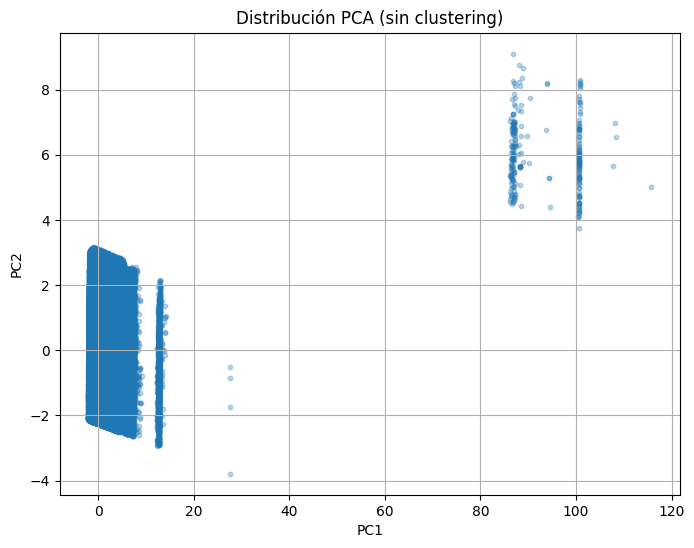

In [ ]:
# ===========================================
# REDUCCIÓN DE DIMENSIONALIDAD CON PCA
# ===========================================
from sklearn.decomposition import PCA

# PCA para reducción a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualizar
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=10)
plt.title("Distribución PCA (sin clustering)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


In [ ]:
# ===========================================
# CONFIGURACIÓN Y CARGA DE DATOS POR LOTES
# ===========================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA
from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.utils import resample
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os

# Configuración
RUTA = '/content/drive/MyDrive/ecobici_resultados/ecobici_continuas.csv'
CHUNK_SIZE = 100_000_000
SAMPLE_SIZE = 1000000
N_CLUSTERS = 5
RANDOM_STATE = 42

# Obtener número de columnas numéricas
first_chunk = pd.read_csv(RUTA, nrows=1)
n_features = first_chunk.select_dtypes(include=np.number).shape[1]
n_components_ipca = min(n_features, 7)

# PCA Incremental para clustering y visualización
ipca = IncrementalPCA(n_components=n_components_ipca, batch_size=CHUNK_SIZE)
ipca_vis = IncrementalPCA(n_components=2, batch_size=CHUNK_SIZE)

print("🔄 Entrenando PCA Incremental...")
for chunk in pd.read_csv(RUTA, chunksize=CHUNK_SIZE):
    X = chunk.select_dtypes(include=np.number)
    X_scaled = StandardScaler().fit_transform(X)
    ipca.partial_fit(X_scaled)

# Obtener muestra representativa
print("\n⚙️ Muestreando datos para clustering aglomerativo y GMM...")
X_sample = None

for chunk in pd.read_csv(RUTA, chunksize=CHUNK_SIZE):
    X = chunk.select_dtypes(include=np.number)
    X_scaled = StandardScaler().fit_transform(X)
    X_pca = ipca.transform(X_scaled)

    sampled = resample(X_pca, n_samples=SAMPLE_SIZE, random_state=RANDOM_STATE)
    X_sample = sampled if X_sample is None else np.vstack([X_sample, sampled])
    X_sample = resample(X_sample, n_samples=SAMPLE_SIZE, random_state=RANDOM_STATE)

ipca_vis.partial_fit(X_sample)
X_sample_vis = ipca_vis.transform(X_sample)

# Entrenamiento de modelos
print("\n🔍 Entrenando modelos de clustering...")

print("- MiniBatch K-Means")
mbk = MiniBatchKMeans(n_clusters=N_CLUSTERS, batch_size=CHUNK_SIZE, compute_labels=True, random_state=RANDOM_STATE)
for chunk in pd.read_csv(RUTA, chunksize=CHUNK_SIZE):
    X = chunk.select_dtypes(include=np.number)
    X_scaled = StandardScaler().fit_transform(X)
    X_pca = ipca.transform(X_scaled)
    mbk.partial_fit(X_pca)

print("- Agglomerative Clustering")
agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
agg_labels = agg.fit_predict(X_sample)

print("- Gaussian Mixture")
gm = GaussianMixture(n_components=N_CLUSTERS, covariance_type='diag', max_iter=100, random_state=RANDOM_STATE, verbose=1)
gm.fit(X_sample)

# 4. Visualización
tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_sample_vis)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=mbk.predict(X_sample), cmap='viridis', alpha=0.5)
plt.title('MiniBatch K-Means Clusters')

plt.subplot(1, 3, 2)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=agg_labels, cmap='viridis', alpha=0.5)
plt.title('Agglomerative Clustering')

plt.subplot(1, 3, 3)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=gm.predict(X_sample), cmap='viridis', alpha=0.5)
plt.title('Gaussian Mixture')

plt.tight_layout()
plt.show()

print("\n✅ Proceso completado!")


🔄 Entrenando PCA Incremental...


Comparación de modelos

In [ ]:
# ===========================================
# COMPARACIÓN DE MODELOS
# ===========================================
agg_metrics = {
    'Silhouette': silhouette_score(X_sample, agg_labels),
    'Calinski-Harabasz': calinski_harabasz_score(X_sample, agg_labels),
    'Davies-Bouldin': davies_bouldin_score(X_sample, agg_labels)
}
kmeans_labels = mbk.predict(X_sample)
kmeans_metrics = {
    'Silhouette': silhouette_score(X_sample, kmeans_labels),
    'Calinski-Harabasz': calinski_harabasz_score(X_sample, kmeans_labels),
    'Davies-Bouldin': davies_bouldin_score(X_sample, kmeans_labels)
}
gmm_labels = gm.predict(X_sample)
gmm_metrics = {
    'Silhouette': silhouette_score(X_sample, gmm_labels),
    'Calinski-Harabasz': calinski_harabasz_score(X_sample, gmm_labels),
    'Davies-Bouldin': davies_bouldin_score(X_sample, gmm_labels)
}

comparison_data = {
    'Agglomerative': agg_metrics,
    'K-Means': kmeans_metrics,
    'Gaussian Mixture': gmm_metrics
}

comparison_df = pd.DataFrame(comparison_data).T

print("\nCOMPARACIÓN DE MODELOS DE CLUSTERING")
print("="*50)
display(comparison_df.style.background_gradient(cmap='Blues'))

plt.figure(figsize=(12, 8))
metrics_to_plot = ['Silhouette', 'Calinski-Harabasz']
for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 1, i)
    comparison_df[metric].plot(kind='bar', color='skyblue')
    plt.title(f'Comparación de {metric}')
    plt.ylabel('Valor')
    plt.xticks(rotation=0)
    plt.grid(axis='y')

plt.tight_layout()
plt.show()

print("\nNota: Para Davies-Bouldin, un valor más bajo indica mejor clustering")

plt.tight_layout()
plt.show()

# Nota sobre Davies-Bouldin (menor es mejor)
print("\nNota: Para Davies-Bouldin, un valor más bajo indica mejor clustering")

Perfilamiento

In [ ]:
# ===========================================
# PERFILAMIENTO DE CLUSTERS (K-MEANS)
# ===========================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Leer nuevamente una muestra representativa del dataset original
df = pd.read_csv(RUTA, nrows=50_000)  # Ajusta según la memoria
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Estandarizar y transformar con PCA entrenado
X_scaled = StandardScaler().fit_transform(df[numeric_cols])
X_pca = ipca.transform(X_scaled)

# Predecir clusters con MiniBatchKMeans
kmeans_labels = mbk.predict(X_pca)
df['Cluster'] = kmeans_labels

# 2. Estadísticas descriptivas por cluster
print("\n📊 ESTADÍSTICAS POR CLUSTER:")
cluster_stats = df.groupby('Cluster')[numeric_cols].mean()
display(cluster_stats.style.background_gradient(cmap='YlOrRd'))

# 3. Tamaño de clusters
plt.figure(figsize=(8, 4))
df['Cluster'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Distribución de Registros por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Número de Registros')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# 4. Características más importantes por cluster
def plot_important_features(cluster_stats, n_features=5):
    global_means = df[numeric_cols].mean()
    n_clusters = cluster_stats.shape[0]

    plt.figure(figsize=(4 * n_clusters, 6))

    for cluster in cluster_stats.index:
        important_features = cluster_stats.loc[cluster].sub(global_means).abs().nlargest(n_features).index

        plt.subplot(1, n_clusters, cluster + 1)
        width = 0.35
        x = np.arange(n_features)

        plt.bar(x - width/2, global_means[important_features], width, label='Global', color='lightblue', alpha=0.6)
        plt.bar(x + width/2, cluster_stats.loc[cluster, important_features], width, label=f'Cluster {cluster}', color='darkred', alpha=0.8)

        plt.title(f'Cluster {cluster}')
        plt.xticks(ticks=x, labels=important_features, rotation=45, ha='right')
        plt.ylabel('Valor Promedio')
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_important_features(cluster_stats)